In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from argparse import ArgumentParser


def normalization(pts):
    # Normalizing the input points #
    # Find the centroid of the points (find the mean x and mean y value)
    centroid = np.array([np.mean(pts[:, 0]), np.mean(pts[:, 1])])

    # Compute the mean distance of all the points from this centroid
    distance = 0
    for index in range(pts[:, 0].size):
        distance += np.linalg.norm(centroid - pts[index, :])
    meanDistance = distance / pts[:, 0].size

    # Construct a 3 by 3 matrix that would translate the points so that the mean distance would be sqrt(2)
    T = np.array([[np.sqrt(2) / meanDistance, 0, -centroid[0] * np.sqrt(2) / meanDistance],
                  [0, np.sqrt(2) / meanDistance, -centroid[1] * np.sqrt(2) / meanDistance],
                  [0, 0, 1]])

    # Normalize points
    result = np.ones((pts[:, 0].size, 2), dtype=float)
    for index in range(pts[:, 0].size):
        current = np.dot(T, np.array([pts[index, 0], pts[index, 1], 1]))
        # we are only interested in x & y
        result[index, 0] = current[0]
        result[index, 1] = current[1]

    return result, T

In [2]:
def FM_by_normalized_8_point(pts1, pts2):
    # F, _ = cv2.findFundamentalMat(pts1, pts2, cv2.FM_8POINT)
    # comment out the above line of code.

    # Normalizing points
    normalizedPts1, T1 = normalization(pts1)
    normalizedPts2, T2 = normalization(pts2)

    u1 = normalizedPts1[:, 0]
    v1 = normalizedPts1[:, 1]
    u2 = normalizedPts2[:, 0]
    v2 = normalizedPts2[:, 1]
    ones = np.ones(normalizedPts1[:, 0].size, int)

    # Create the constraint matrix
    A = np.array([u1 * u2, u1 * v2, u1, v1 * u2, v1 * v2, v1, u2, v2, ones]).transpose()
    U, D, V = np.linalg.svd(A)

    # Extract fundamental matrix from the column of V corresponding to the smallest singular value
    FMatrix = np.reshape(V.transpose()[:, 8], (3, 3)).transpose()

    # Enforce rank2 constraint
    U, D, V = np.linalg.svd(FMatrix)
    FMatrix = U @ np.diag(np.array([D[0], D[1], 0])) @ V

    # De-normalize
    FMatrix = T2.transpose() @ FMatrix @ T1
    ##############################################################################################

    # normalize the fundamental matrix so that the value on [2, 2] is 1
    FMatrix = np.true_divide(FMatrix, FMatrix[2, 2])

    return FMatrix

In [3]:
def FM_by_RANSAC(pts1, pts2):
    # F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
    # comment out the above line of code.

    samplePointCount = 8
    totalPointCount = pts1[:, 0].size
    maxInlier = -9999
    # adjust numberOfIteration & threshold to see different results #
    numberOfIteration = 10000
    threshold = 0.2

    # Initialize the final fundamental matrix and final mask
    finalFMatrix = np.zeros((3, 3), dtype=float)
    finalMask = np.zeros((totalPointCount, 1), dtype=int)

    for iterate in range(numberOfIteration):
        tempMask = np.zeros((totalPointCount, 1), dtype=int)    # initialize temp mask
        # random select 8 points from pts1 & pts2 between 0 - totalPointCount
        randomIndexes = np.random.choice(totalPointCount, samplePointCount, replace=False)
        samplePts1 = pts1[randomIndexes]
        samplePts2 = pts2[randomIndexes]

        tempFMatrix = FM_by_normalized_8_point(samplePts1, samplePts2)      # calculate FMatrix

        # add one behind points in order to make the matrix multiplication to FMatrix (3x3) possible
        oneByThreeSamplePts1 = np.c_[pts1, np.ones(totalPointCount)]
        oneByThreeSamplePts2 = np.c_[pts2, np.ones(totalPointCount)]

        for index in range(totalPointCount):
            # Compute the difference
            difference = abs(oneByThreeSamplePts1[index].transpose() @ tempFMatrix @ oneByThreeSamplePts2[index])
            # the number is inlier if the difference is smaller than the threshold
            if difference < threshold:
                tempMask[index, 0] = 1

        # compare if the inliers in tempMask is bigger than the maxInlier. If so, update the finalMask and finalFMatrix
        if np.count_nonzero(tempMask == 1, axis=0) > maxInlier:
            maxInlier = np.count_nonzero(tempMask == 1, axis=0)
            finalMask = tempMask
            finalFMatrix = tempFMatrix

    return finalFMatrix, finalMask


In [4]:
def drawlines(img1, img2, lines, pts1, pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r, c = img1.shape
    img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    for r, pt1, pt2 in zip(lines, pts1, pts2):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        x0, y0 = map(int, [0, -r[2] / r[1]])
        x1, y1 = map(int, [c, -(r[2] + r[0] * c) / r[1]])
        img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 1)
        img1 = cv2.circle(img1, tuple(pt1), 5, color, -1)
        img2 = cv2.circle(img2, tuple(pt2), 5, color, -1)
    return img1, img2

In [6]:
if __name__ == '__main__':
    parser = ArgumentParser()
    parser.add_argument("--UseRANSAC", type=int, default=0)
    parser.add_argument("--image1", type=str, default= './img1.png')
    parser.add_argument("--image2", type=str, default= './img2.png')
    args, unknown = parser.parse_known_args()

    print(args)

    img1 = cv2.imread(args.image1, 0)
    img2 = cv2.imread(args.image2, 0)

    sift = cv2.xfeatures2d.SIFT_create()

    # find the keypoints and descriptors with SIFT
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # FLANN parameters
    FLANN_INDEX_KDTREE = 0
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    good = []
    pts1 = []
    pts2 = []


Namespace(UseRANSAC=0, image1='./img1.png', image2='./img2.png')


In [7]:
    # ratio test as per Lowe's paper
    for i, (m, n) in enumerate(matches):
        if m.distance < 0.8 * n.distance:
            good.append(m)
            pts2.append(kp2[m.trainIdx].pt)
            pts1.append(kp1[m.queryIdx].pt)

    pts1 = np.int32(pts1)
    pts2 = np.int32(pts2)

    F = None
    if args.UseRANSAC:
        F, mask = FM_by_RANSAC(pts1, pts2)
        # We select only inlier points
        pts1 = pts1[mask.ravel() == 1]
        pts2 = pts2[mask.ravel() == 1]
    else:
        F = FM_by_normalized_8_point(pts1, pts2)

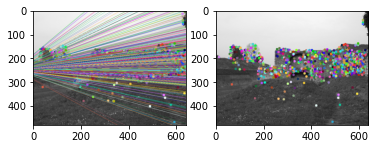

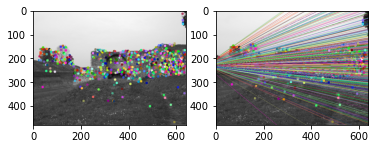

In [8]:

    # Find epilines corresponding to points in second image,  and draw the lines on first image
    lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2, F)
    lines1 = lines1.reshape(-1, 3)
    img5, img6 = drawlines(img1, img2, lines1, pts1, pts2)
    plt.subplot(121), plt.imshow(img5)
    plt.subplot(122), plt.imshow(img6)
    plt.show()

    # Find epilines corresponding to points in first image, and draw the lines on second image
    lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
    lines2 = lines2.reshape(-1, 3)
    img3, img4 = drawlines(img2, img1, lines2, pts2, pts1)
    plt.subplot(121), plt.imshow(img4)
    plt.subplot(122), plt.imshow(img3)
    plt.show()